In [2]:
import utils
import rasterio
import os
import sklearn.metrics
import numpy as np

import matplotlib.pyplot as plt

from importlib import reload
reload(utils)

<module 'utils' from '/n/home10/erolf/tree_mapping/utils.py'>

In [3]:
def get_site_lidar_tif_fn(eval_site_id,data_dir):
    site_dir = data_dir + f'/lidar/Karingani_merged_crs_10/site_{eval_site_id}'
    tifs_this_site = [x for x in os.listdir(site_dir) if x.endswith('.tif')]
    
    assert len(tifs_this_site) == 1
    
    return os.path.join(site_dir,tifs_this_site[0])

def match_map_to_labels(eval_site_id, 
                        compare_identifier='eth',
                        data_dir = 'data'):
    
    compare_identifier = compare_identifier.lower()

    # eth
    if compare_identifier == 'eth':
        eth_map_fn = data_dir + '/raw/global_tch_maps/ETH_GlobalCanopyHeight_10m_2020_S27E030_Map.tif'


    out_dir = data_dir + '/output' + '/{compare_identifier}_map'
    out_fn = os.path.join(out_dir, f'site_{eval_site_id}_{compare_identifier}_map.tif')
    if not os.path.exists(out_dir):
        os.mkdir(out_dir)

    
    target_fn = get_site_lidar_tif_fn(eval_site_id, data_dir)
    
    utils.match_input_to_target_tif(input_fn = eth_map_fn, 
                                    output_fn = out_fn, 
                                    target_fn = target_fn)
                     
    return out_fn                
    
    
def compare_aligned_data(labels, preds):
    
    mask = labels >= 0
    labels_ = labels[mask].ravel()
    preds_ = preds[mask].ravel()
    
    r2 = sklearn.metrics.r2_score(labels_,preds_)
    mae = sklearn.metrics.mean_absolute_error(labels_,preds_)
    mse = sklearn.metrics.mean_squared_error(labels_,preds_)

    return {'r2':r2, 'mae':mae, 'mse':mse}

def plot_aligned_data(labels, preds, vis=None,
                      title='title me!'):
    if vis is None:
        fig, ax = plt.subplots(1,2, figsize=(12*4,6*4))
    else:
        fig, ax = plt.subplots(1,3, figsize=(18*4,6*4))
    
    ymax = labels.max()
    ax[0].imshow(labels[0], vmin=0, vmax=ymax, cmap='Greens')
    ax[0].set_title('CHM data')
    
    preds_show = preds.copy()
    mask = labels > 0
    preds_show[~mask] = 0
    ax[1].imshow(preds_show[0], vmin=0, vmax=ymax, cmap='Greens')
    ax[1].set_title('reference data / predictions')
    
    if vis is not None:
        ax[2].imshow(vis_.transpose(1,2,0).astype(int), 'visual image')
    plt.suptitle(title)
        

In [4]:
eval_site_id = 13
compare_identifier = 'eth'

def eval_tif_at_cite(eval_site_id, compare_identifier, data_dir ='data', plot=True):
    cropped_map_fn = match_map_to_labels(eval_site_id = eval_site_id, 
                                         compare_identifier = compare_identifier)

    with rasterio.open(cropped_map_fn) as f:
        cropped_map = f.read()
        nodata_val = f.nodata
        
    if (cropped_map == nodata_val).all():
        print('reference data all nans - did you check that this matches the extend of the labels?')
        return {'r2':np.nan, 'mae':np.nan, 'mse':np.nan}
    elif (cropped_map == nodata_val).any():
        print('reference data contains nans - did you check that this matches the extend of the labels?')
        return {'r2':np.nan, 'mae':np.nan, 'mse':np.nan}
    
    labels_fn = get_site_lidar_tif_fn(eval_site_id,data_dir)

    with rasterio.open(labels_fn) as f:
        labels = f.read()

    assert labels.shape == cropped_map.shape
    
    if plot:
        plot_aligned_data(labels, cropped_map, vis=None,
                          title=f'site {eval_site_id}')

    return compare_aligned_data(labels, cropped_map)

def baseline_predict_mean_per_cite(eval_site_id, data_dir ='data'):
    labels_fn = get_site_lidar_tif_fn(eval_site_id,data_dir)
    with rasterio.open(labels_fn) as f:
        labels = f.read()
    mask = labels >= 0 
    return compare_aligned_data(labels, np.ones_like(labels) * labels[mask].mean())

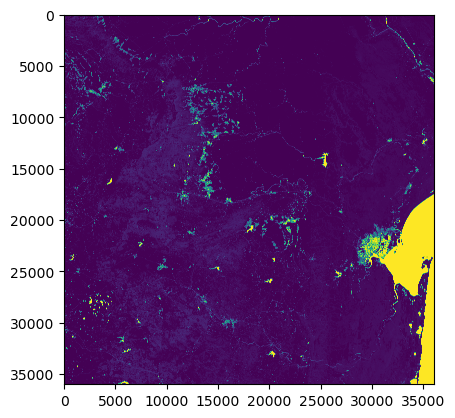

In [5]:
with rasterio.open('data/raw/global_tch_maps/ETH_GlobalCanopyHeight_10m_2020_S27E030_Map.tif') as f:
    full_map = f.read()
    
plt.imshow(full_map[0])

Creating output file that is 479P x 482L.
Processing data/raw/global_tch_maps/ETH_GlobalCanopyHeight_10m_2020_S27E030_Map.tif [1/1] : 0Using internal nodata values (e.g. 255) for image data/raw/global_tch_maps/ETH_GlobalCanopyHeight_10m_2020_S27E030_Map.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
saved in data/output/{compare_identifier}_map/site_6_eth_map.tif
Creating output file that is 481P x 492L.
Processing data/raw/global_tch_maps/ETH_GlobalCanopyHeight_10m_2020_S27E030_Map.tif [1/1] : 0Using internal nodata values (e.g. 255) for image data/raw/global_tch_maps/ETH_GlobalCanopyHeight_10m_2020_S27E030_Map.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
saved in data/output/{compare_identifier}_map/site_13_eth_map.tif
Creating output file that is 479P x 491L.
Processing data/raw/global_tch_maps/ETH_GlobalCanopyHeight_10m_2020_S27E030_Map.tif [1/1] : 0Using internal nodata values (e.g. 255) for image data/raw/global_tch_maps/ETH_GlobalCanopyHeigh

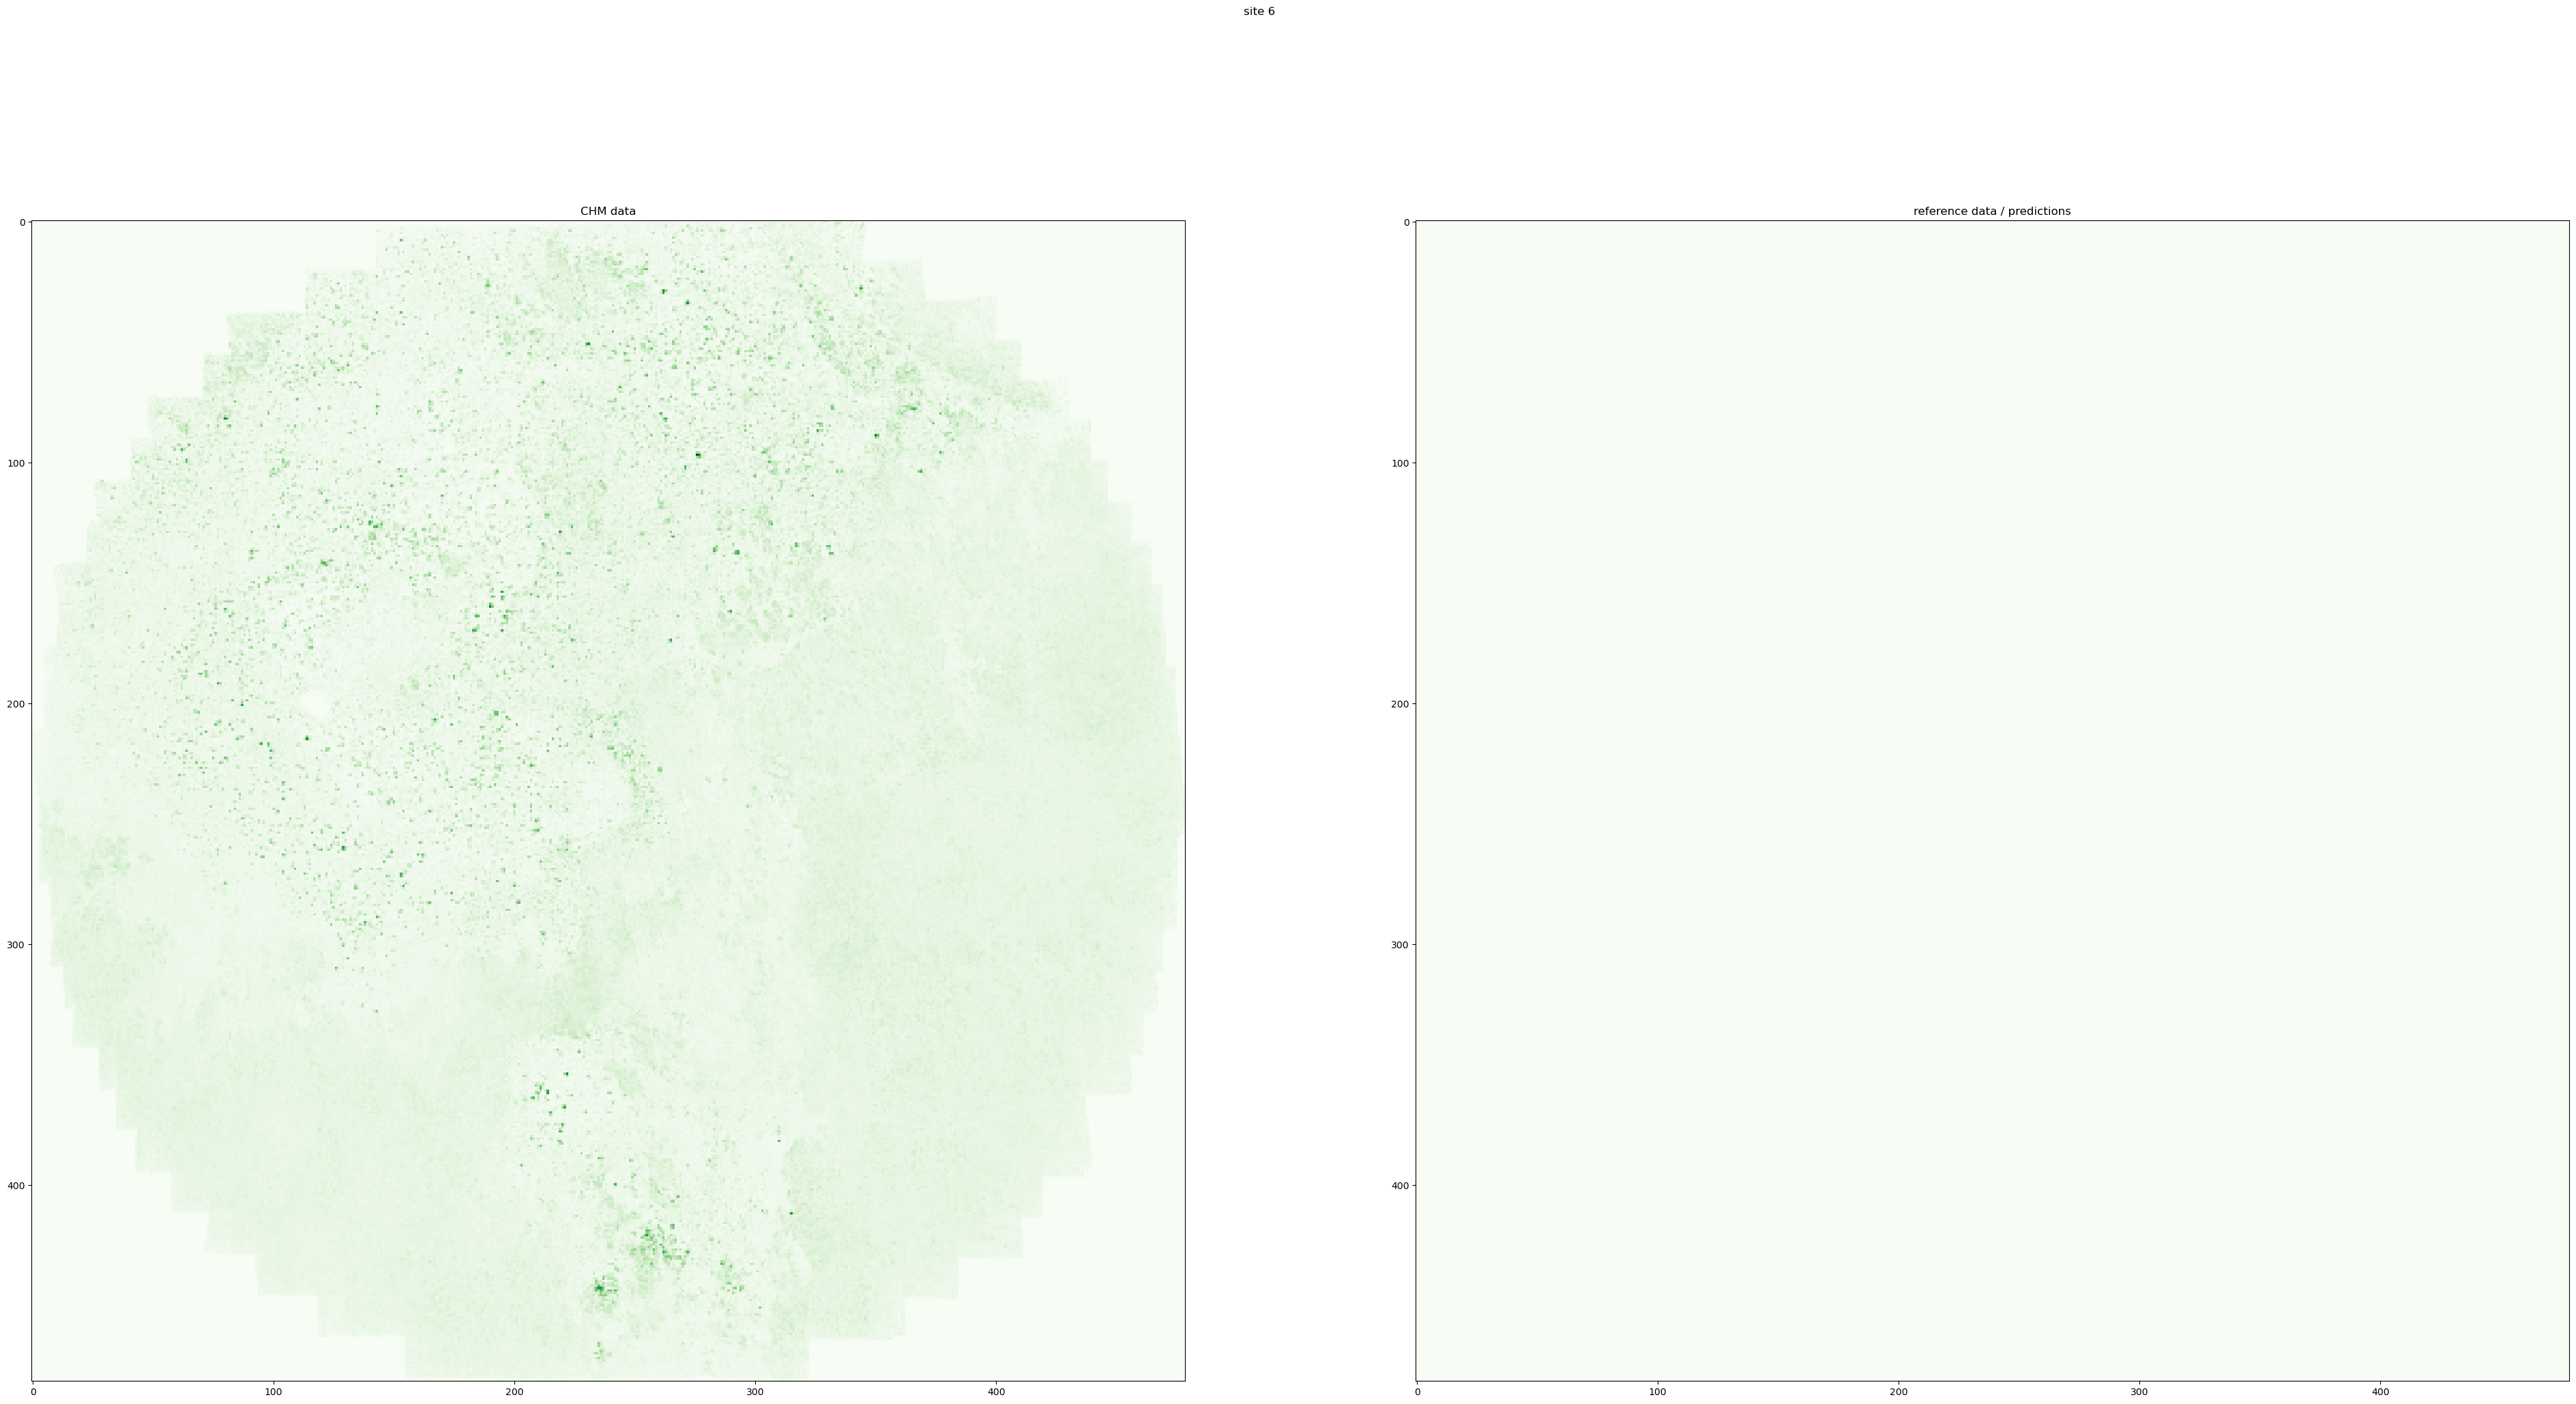

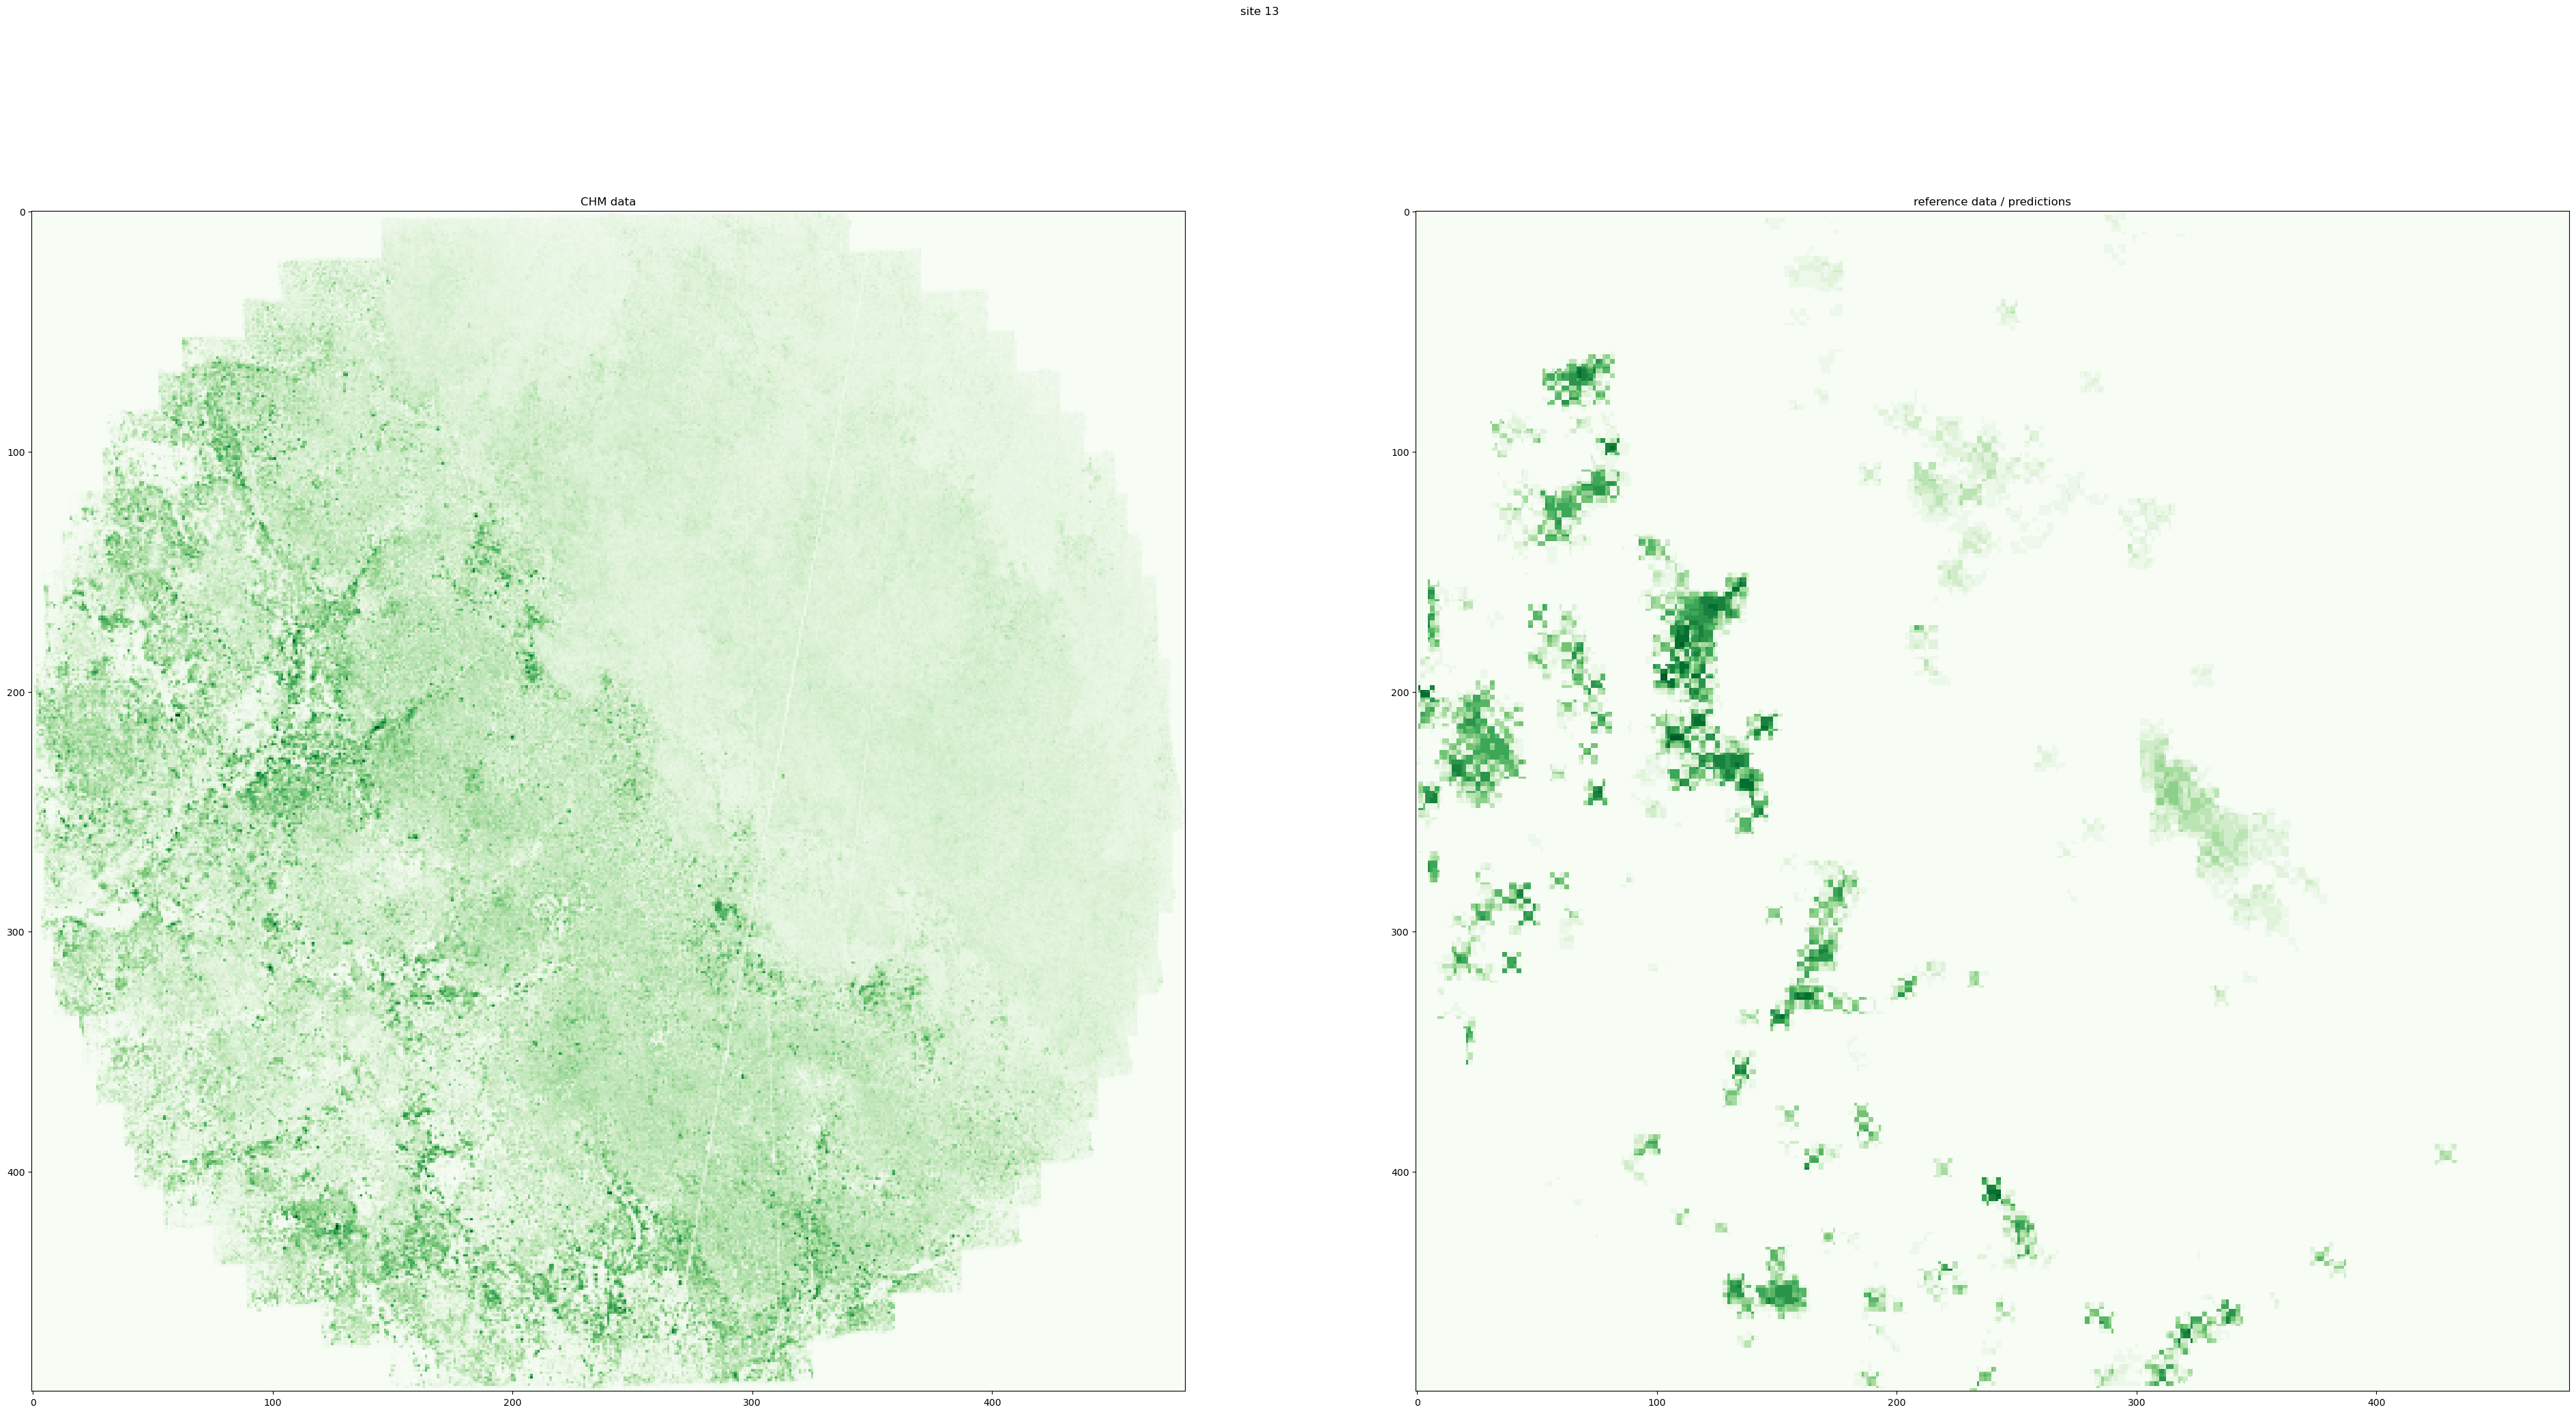

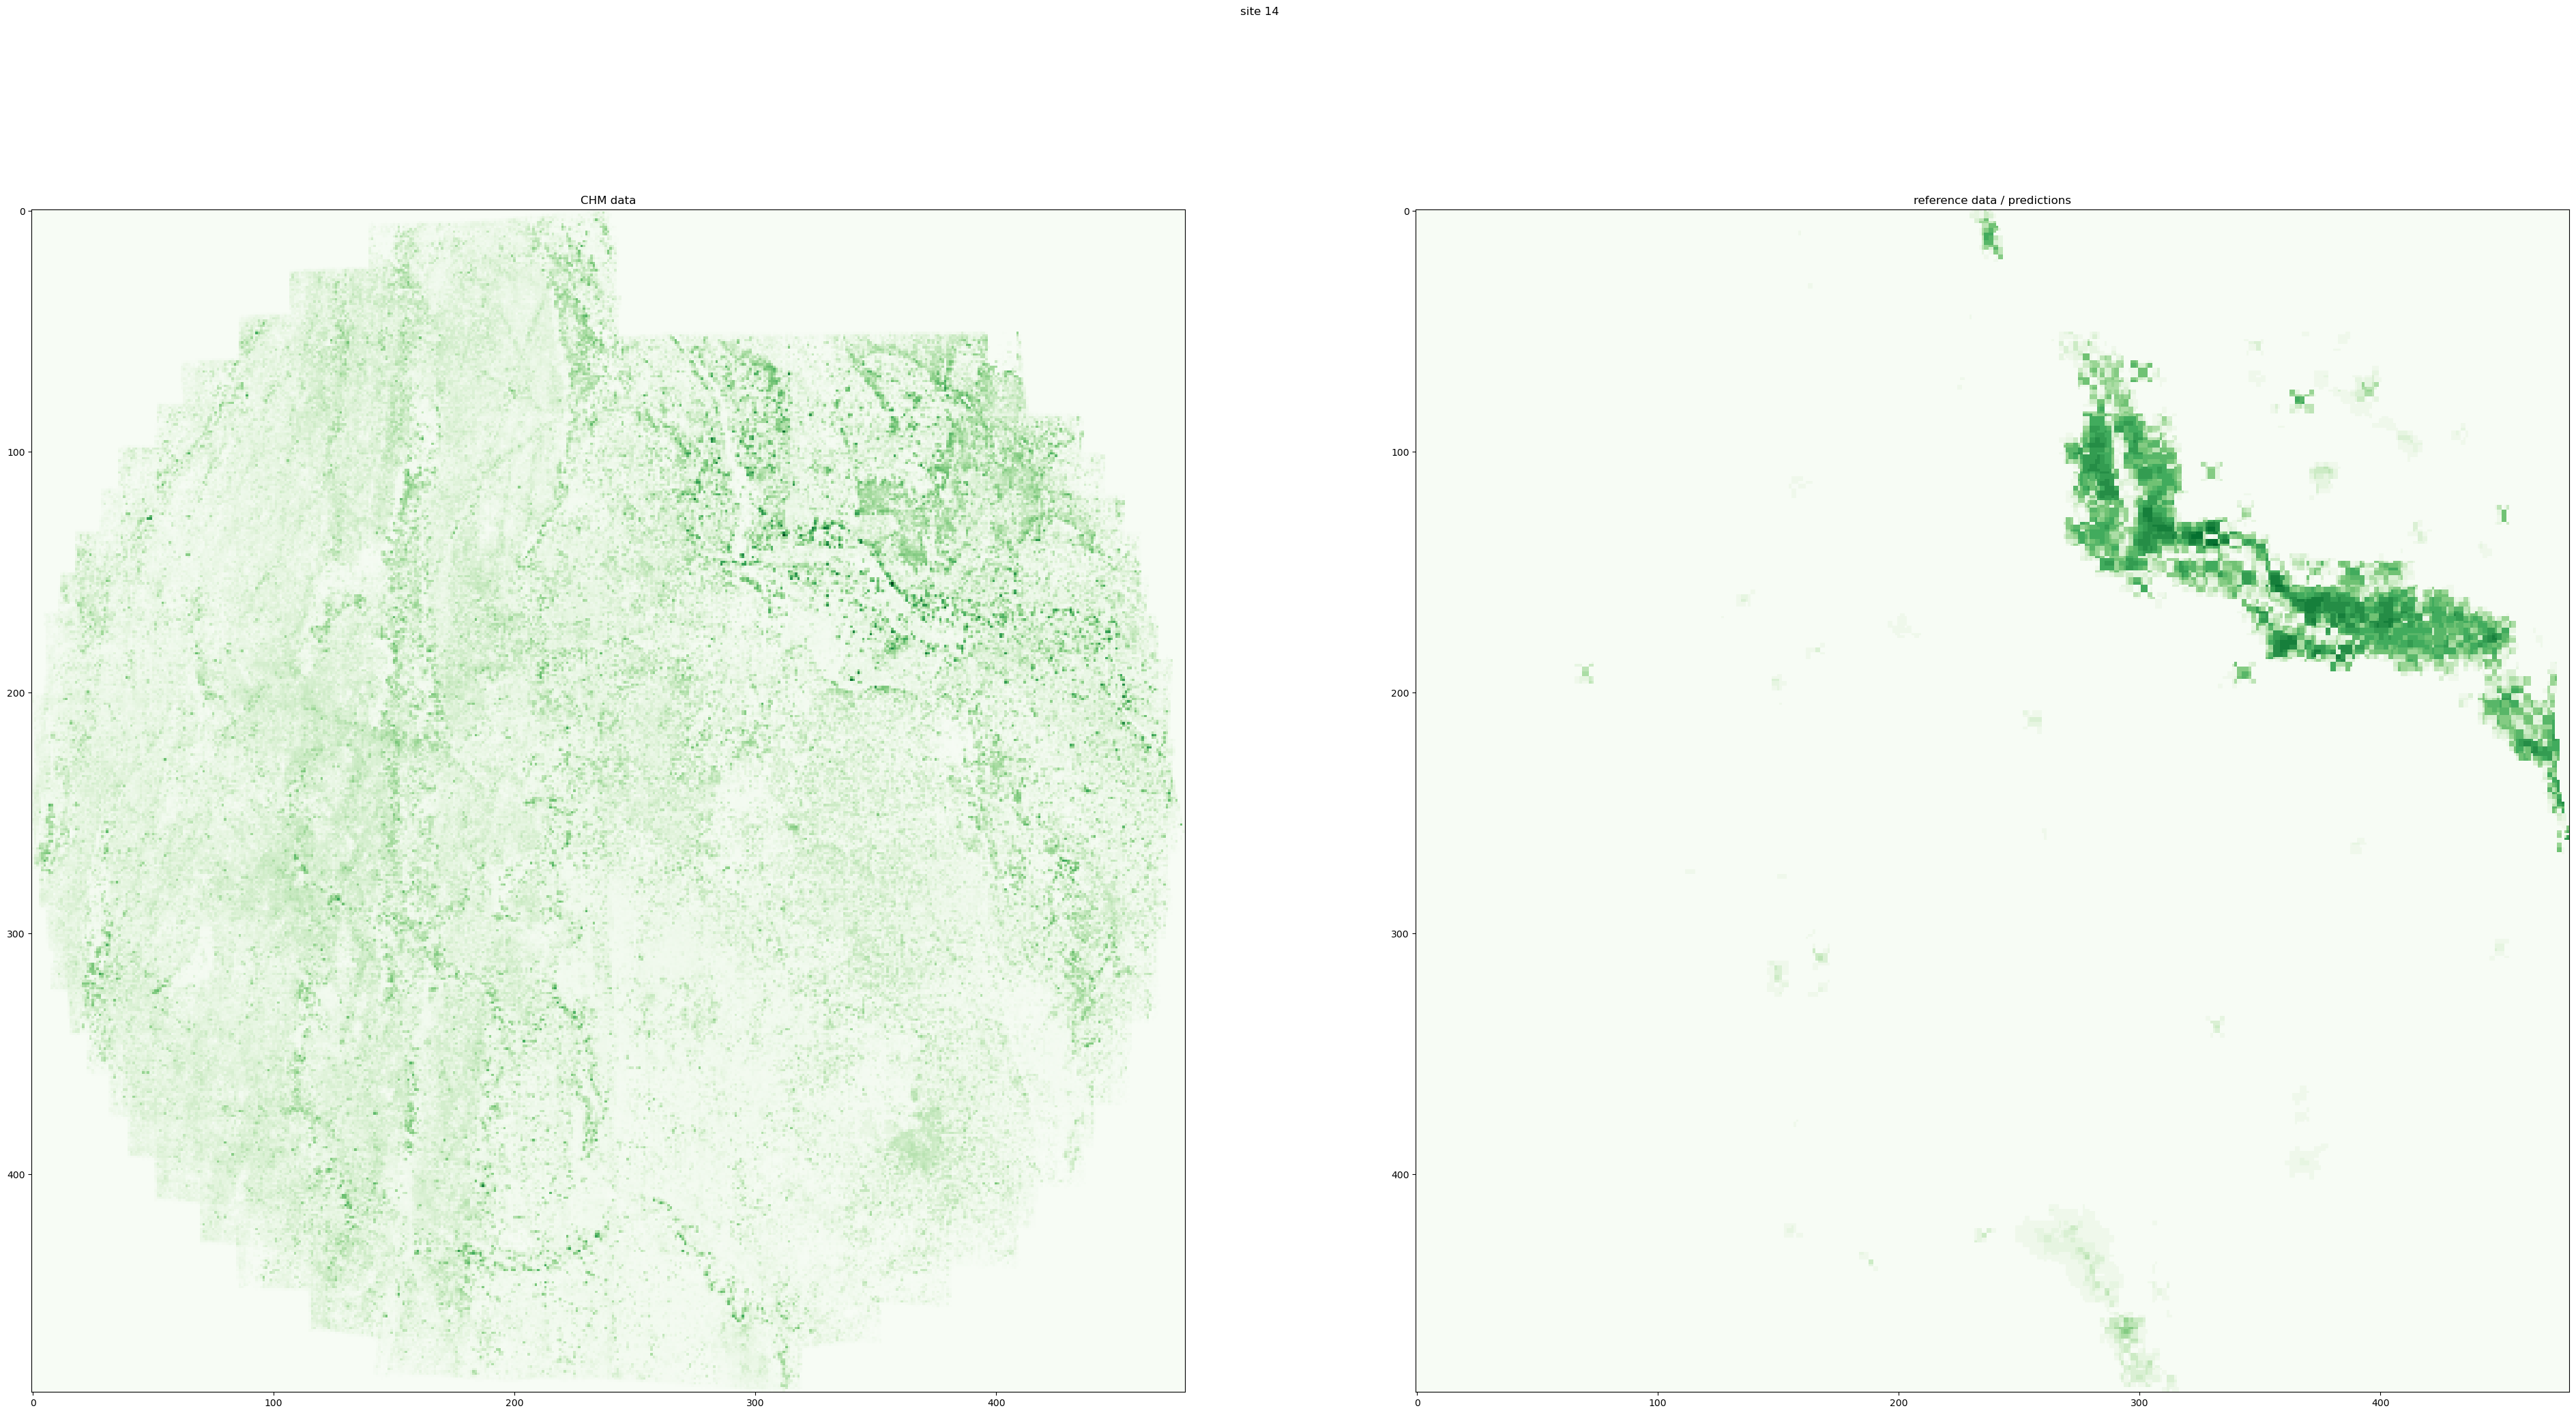

In [6]:
eval_site_ids = [6,13,14]

eth_compares = {}
mean_dummy_compares = {}

for eval_site_id in eval_site_ids:
    eth_compares[eval_site_id] = eval_tif_at_cite(eval_site_id, 'eth')
    mean_dummy_compares[eval_site_id] = baseline_predict_mean_per_cite(eval_site_id)

In [7]:
eth_compares

{6: {'r2': -3.9571009265512194, 'mae': 1.5427383, 'mse': 2.981503},
 13: {'r2': -3.427231711080468, 'mae': 2.7169418, 'mse': 9.536265},
 14: {'r2': -2.285337406202962, 'mae': 2.3030493, 'mse': 8.292514}}

In [8]:
mean_dummy_compares

{6: {'r2': 0.0, 'mae': 0.5345705, 'mse': 0.60146105},
 13: {'r2': 0.0, 'mae': 1.1065142, 'mse': 2.1540015},
 14: {'r2': 0.0, 'mae': 1.1952361, 'mse': 2.5240984}}